# DBSCAN alinhado ao experimento do XGBoost

Este notebook adapta o DBSCAN para utilizar **o mesmo conjunto de dados, split temporal, engenharia de features, remoção de colunas, target encoding e StandardScaler** do notebook `XGBoost_temporal_split(5).ipynb`.

### Importante sobre o balanceamento
O XGBoost de referência calcula a razão entre classes (`max_spw`), mas **não aplica `scale_pos_weight`, SMOTE, undersampling ou oversampling no modelo final**. Portanto, para manter a comparação equivalente, este DBSCAN também não realiza reamostragem.

### Diferença metodológica
DBSCAN é um algoritmo **não supervisionado**. Por isso:
- `delivered_on_time` não participa da formação dos clusters;
- não existem parâmetros como `n_estimators`, `max_depth`, `learning_rate` ou `scale_pos_weight`;
- os hiperparâmetros próprios do DBSCAN são principalmente `eps` e `min_samples`;
- as classes reais de atraso são usadas somente **depois** do agrupamento, para analisar a composição dos clusters.


In [10]:
# Célula 1: bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import DBSCAN
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## Preparação dos dados

A célula abaixo foi alinhada à preparação usada no XGBoost. Assim, o DBSCAN recebe as mesmas informações que o XGBoost recebeu antes do treinamento.


In [11]:
# Celula 2: leitura da base e preparo das variaveis de entrada.
csv_path = Path("../../tabela_final/table_orders_holidays_ecommerce_events.csv") # Path(r"C:\Users\otavi\OneDrive\Desktop\last-mile-tcc\backend\tabela_final\table_orders_holidays_ecommerce_events.csv")
df = pd.read_csv(csv_path)

target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# =====================================================================
# 1. ENGENHARIA DO SLA (Prazo da Transportadora - LAST MILE)
# =====================================================================
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], utc=True)
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], utc=True)
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Quantos dias a transportadora tem para entregar apos pegar o pacote?
df['prazo_transportadora_dias'] = (df['order_estimated_delivery_date'] - df['order_delivered_carrier_date']).dt.days

# Remover os casos onde a transportadora nunca pegou o pacote para evitar NaN no treino
df = df.dropna(subset=['prazo_transportadora_dias']).copy()

# Extraindo o mes da compra (sazonalidade - Black Friday, Natal)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
# df['carrier_month'] = df['order_delivered_carrier_date'].dt.month

# =====================================================================
# 1b. FEATURES DE INTERAÇÃO (Adicionadas para aumentar o sinal)
# =====================================================================
df['prazo_por_km'] = df['prazo_transportadora_dias'] / (df['distance_km'] + 1)
df['frete_por_kg'] = df['freight_value'] / (df['product_weight_g'] / 1000 + 0.1)
df['densidade_produto'] = df['product_weight_g'] / (df['volume_cm3'] + 1)

# =====================================================================
# 2. ORDENAÇÃO CRONOLÓGICA (Baseada no momento da coleta)
# =====================================================================
df = df.sort_values('order_delivered_carrier_date').reset_index(drop=True)

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
date_col = df['order_delivered_carrier_date'].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
# Inverte o alvo: atraso = 1, no prazo = 0.
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier", # variável n ajudou no modelo
    "interval_code_delivered_customer",
    "order_estimated_delivery_date", # Ja usamos
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    # "had_ecommerce_event_14_days_ago",

    # --- FEATURES REDUNDANTES / BAIXA INFLUENCIA REMOVIDAS ---
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend"
]

# colunas_remover = [
#     # Vazamento de dados / multicolinearidade
#     "order_purchase_timestamp",
#     "order_approved_at",
#     "order_delivered_carrier_date",
#     "interval_code_delivered_carrier",
#     "order_delivered_customer_date",
#     "interval_code_delivered_customer",
#     "order_estimated_delivery_date",
#     "shipping_limit_date",
#     "is_holiday_in_7_days",
#     "is_holiday_in_14_days",
#     "had_holiday_7_days_ago",
#     "had_holiday_14_days_ago",
#     "delivered_on_time",
#     # "customer_city", # Mantido para Target Encoding
#     # "seller_city", # Mantido para Target Encoding
#     # "category_name", # Mantido para Target Encoding
#     "review_score",
#     "delivery_time_days"
# ]

X = X.drop(columns=colunas_remover, errors='ignore')

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# =====================================================================
# ENGENHARIA DE FEATURES: TARGET ENCODING SUAVIZADO (Cidades)
# =====================================================================
media_global_atraso = y_train.mean()
m = 10 

# Target encoding para customer_city
counts_customer = X_train['customer_city'].value_counts()
means_customer = y_train.groupby(X_train['customer_city']).mean()
smooth_customer = (counts_customer * means_customer + m * media_global_atraso) / (counts_customer + m)

# Target encoding para seller_city
counts_seller = X_train['seller_city'].value_counts()
means_seller = y_train.groupby(X_train['seller_city']).mean()
smooth_seller = (counts_seller * means_seller + m * media_global_atraso) / (counts_seller + m)

# Aplicando as features
X_train['customer_city_encoded'] = X_train['customer_city'].map(smooth_customer)
X_train['seller_city_encoded'] = X_train['seller_city'].map(smooth_seller)

# No teste, o que não existir no treino vai preencher com a média global
X_test['customer_city_encoded'] = X_test['customer_city'].map(smooth_customer).fillna(media_global_atraso)
X_test['seller_city_encoded'] = X_test['seller_city'].map(smooth_seller).fillna(media_global_atraso)

# Target encoding para category_name (preenchendo nulos com 'Unknown')
X_train['category_name'] = X_train['category_name'].fillna('Unknown')
X_test['category_name'] = X_test['category_name'].fillna('Unknown')
counts_cat = X_train['category_name'].value_counts()
means_cat = y_train.groupby(X_train['category_name']).mean()
smooth_cat = (counts_cat * means_cat + m * media_global_atraso) / (counts_cat + m)
X_train['category_name_encoded'] = X_train['category_name'].map(smooth_cat).fillna(media_global_atraso)
X_test['category_name_encoded'] = X_test['category_name'].map(smooth_cat).fillna(media_global_atraso)

# Agora podemos dropar as strings originais
X_train = X_train.drop(columns=['customer_city', 'seller_city', 'category_name'])
X_test = X_test.drop(columns=['customer_city', 'seller_city', 'category_name'])

# =====================================================================
# STANDARDSCALER: normaliza as features numéricas (incluindo as recém criadas)
# =====================================================================
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

pos_count = int((y_train == 1).sum())
total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: Linhas: {X.shape[0]:,} | Colunas: {X.shape[1]}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {pos_count} ({(y_train == 1).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {(y_test == 1).sum()} ({(y_test == 1).mean():.2%} do teste)\n")

X_test.head()

# Garantias importantes para o DBSCAN
if list(X_train.columns) != list(X_test.columns):
    raise ValueError("Treino e teste ficaram com conjuntos de features diferentes.")

if X_train.isna().any().any() or X_test.isna().any().any():
    raise ValueError("Existem valores NaN após o pré-processamento.")

if not np.isfinite(X_train.to_numpy()).all() or not np.isfinite(X_test.to_numpy()).all():
    raise ValueError("Existem valores infinitos após o pré-processamento.")

print("\nFeatures finais utilizadas pelo DBSCAN:")
print(X_train.columns.tolist())
print(f"\nQuantidade de features: {X_train.shape[1]}")
print(f"Proporção de atrasos no treino: {y_train.mean():.2%}")
print(f"Proporção de atrasos no teste: {y_test.mean():.2%}")


Total de registros: Linhas: 33,820 | Colunas: 26

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)


Features finais utilizadas pelo DBSCAN:
['holiday_at_carrier', 'days_since_last_holiday', 'days_until_next_holiday', 'ecommerce_event_at_carrier', 'days_since_last_ecommerce_event', 'days_until_next_ecommerce_event', 'is_ecommerce_event_in_7_days', 'is_ecommerce_event_in_14_days', 'had_ecommerce_event_7_days_ago', 'had_ecommerce_event_14_days_ago', 'purchase_hour', 'purchase_day_of_week', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city', 'prazo_transportadora_dias', 'purchase_month', 'prazo_por_km', 'frete_por_kg', 'densidade_produto', 'customer_city_encoded', 'seller_city_encoded', 'category_name_encoded']

Quantidade de features: 26
Proporção de atrasos no treino: 4.96%
Proporção de atrasos no teste: 11.99%


## Balanceamento com SMOTE

O SMOTE é aplicado **somente no conjunto de treino**, após o split temporal e o pré-processamento. O teste permanece original para evitar data leakage e manter uma avaliação realista.

In [12]:
# SMOTE somente no treino
print("ANTES DO SMOTE")
print(y_train.value_counts().sort_index())
print(y_train.value_counts(normalize=True).sort_index())

smote = SMOTE(sampling_strategy="auto", random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

X_train_smote = pd.DataFrame(X_res, columns=X_train.columns)
y_train_smote = pd.Series(np.asarray(y_res), name=y_train.name)

print("\nDEPOIS DO SMOTE")
print(y_train_smote.value_counts().sort_index())
print(y_train_smote.value_counts(normalize=True).sort_index())
print(f"\nTreino antes: {len(X_train):,}")
print(f"Treino depois: {len(X_train_smote):,}")
print(f"Teste preservado: {len(X_test):,}")

ANTES DO SMOTE
delivered_on_time
0    27281
1     1425
Name: count, dtype: int64
delivered_on_time
0    0.950359
1    0.049641
Name: proportion, dtype: float64

DEPOIS DO SMOTE
delivered_on_time
0    27281
1    27281
Name: count, dtype: int64
delivered_on_time
0    0.5
1    0.5
Name: proportion, dtype: float64

Treino antes: 28,706
Treino depois: 54,562
Teste preservado: 5,114


## Escolha de `eps` e `min_samples`

No notebook antigo, o `eps` era escolhido visualmente. Aqui fazemos uma busca mais reprodutível.

Como DBSCAN é não supervisionado, **o alvo de atraso não é usado para escolher os hiperparâmetros**. A busca considera:
- quantidade de clusters;
- proporção de ruído;
- Silhouette Score.

Para evitar custo excessivo durante a busca, é usada uma amostra determinística do treino apenas para selecionar os parâmetros. Depois, o melhor DBSCAN é ajustado novamente no conjunto de treino completo.


Registros usados na busca: 20,000
min_samples candidatos: [5, 10, 20]
eps candidatos: [2.8108, 3.1685, 3.2691, 3.5172, 3.6632, 3.7553, 4.0723, 4.2085, 4.4265, 4.6642, 4.9979, 5.501]


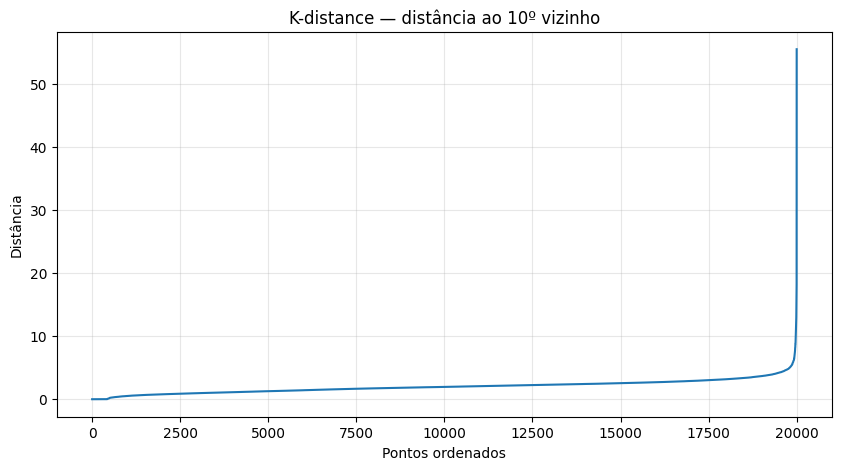

In [13]:
# Célula 3: candidatos de eps a partir das distâncias dos vizinhos

RANDOM_STATE = 42
MAX_TUNING_ROWS = 20000

if len(X_train_smote) > MAX_TUNING_ROWS:
    X_tune = X_train_smote.sample(MAX_TUNING_ROWS, random_state=RANDOM_STATE).copy()
else:
    X_tune = X_train_smote.copy()

print(f"Registros usados na busca: {len(X_tune):,}")

min_samples_candidates = [5, 10, 20]

# Geramos eps candidatos a partir de quantis da distância ao k-ésimo vizinho.
eps_candidates = set()

for min_samples in min_samples_candidates:
    nn = NearestNeighbors(n_neighbors=min_samples, n_jobs=-1)
    nn.fit(X_tune)
    distances, _ = nn.kneighbors(X_tune)
    k_distances = distances[:, -1]

    for q in [0.90, 0.95, 0.975, 0.99]:
        eps_candidates.add(round(float(np.quantile(k_distances, q)), 4))

eps_candidates = sorted(e for e in eps_candidates if e > 0)

print("min_samples candidatos:", min_samples_candidates)
print("eps candidatos:", eps_candidates)

# Gráfico k-distance de referência usando min_samples=10
k_ref = 10
nn_ref = NearestNeighbors(n_neighbors=k_ref, n_jobs=-1)
nn_ref.fit(X_tune)
dist_ref, _ = nn_ref.kneighbors(X_tune)
k_dist_ref = np.sort(dist_ref[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_dist_ref)
plt.title(f"K-distance — distância ao {k_ref}º vizinho")
plt.xlabel("Pontos ordenados")
plt.ylabel("Distância")
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Célula 4: busca dos hiperparâmetros próprios do DBSCAN

resultados_busca = []

for min_samples in min_samples_candidates:
    for eps in eps_candidates:
        modelo = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        )
        labels = modelo.fit_predict(X_tune)

        mask_cluster = labels != -1
        labels_sem_ruido = labels[mask_cluster]
        n_clusters = len(set(labels_sem_ruido))
        noise_ratio = float(np.mean(labels == -1))

        # Silhouette só é definida quando existem pelo menos 2 clusters.
        sil = np.nan
        if n_clusters >= 2 and mask_cluster.sum() > n_clusters:
            # Limita a amostra da silhouette para controlar tempo/memória.
            sil = silhouette_score(
                X_tune.loc[mask_cluster],
                labels_sem_ruido,
                sample_size=min(5000, mask_cluster.sum()),
                random_state=RANDOM_STATE
            )

        resultados_busca.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil
        })

df_busca = pd.DataFrame(resultados_busca)

# Evita soluções degeneradas: nenhum cluster, um único cluster ou ruído extremo.
validos = df_busca[
    (df_busca["n_clusters"] >= 2) &
    (df_busca["noise_ratio"] < 0.80) &
    (df_busca["silhouette"].notna())
].copy()

if validos.empty:
    raise RuntimeError(
        "Nenhuma combinação válida foi encontrada. "
        "Amplie os quantis/candidatos de eps ou reveja min_samples."
    )

# Seleção não supervisionada: maior silhouette; em empate, menos ruído.
validos = validos.sort_values(
    ["silhouette", "noise_ratio"],
    ascending=[False, True]
).reset_index(drop=True)

display(validos.head(10))

best_eps = float(validos.loc[0, "eps"])
best_min_samples = int(validos.loc[0, "min_samples"])

print(f"\nMelhor eps: {best_eps}")
print(f"Melhor min_samples: {best_min_samples}")
print(f"Silhouette da busca: {validos.loc[0, 'silhouette']:.4f}")
print(f"Ruído na busca: {validos.loc[0, 'noise_ratio']:.2%}")


,eps,min_samples,n_clusters,noise_ratio,silhouette
0,3.1685,20,2,0.05880,0.500774
1,3.2691,20,2,0.05105,0.499366
2,3.6632,20,2,0.02935,0.492720
3,3.7553,20,3,0.02475,0.492335
4,3.7553,10,3,0.01710,0.492152
5,4.0723,20,3,0.01610,0.491471
6,4.2085,10,3,0.00985,0.491310
7,3.6632,10,3,0.02015,0.491283
8,3.5172,5,5,0.01950,0.490621
9,4.4265,10,3,0.00775,0.490512



Melhor eps: 3.1685
Melhor min_samples: 20
Silhouette da busca: 0.5008
Ruído na busca: 5.88%


## Treinamento final e análise dos clusters

O DBSCAN final é ajustado no **treino completo**. A variável de atraso continua fora do treinamento e entra somente na avaliação posterior.


In [15]:
# Célula 5: DBSCAN final no treino completo

dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    n_jobs=-1
)

cluster_train = dbscan_final.fit_predict(X_train_smote)

n_clusters_train = len(set(cluster_train)) - (1 if -1 in cluster_train else 0)
n_noise_train = int(np.sum(cluster_train == -1))

print(f"Clusters encontrados no treino: {n_clusters_train}")
print(f"Registros classificados como ruído: {n_noise_train:,} ({n_noise_train/len(cluster_train):.2%})")

resultado_train = pd.DataFrame({
    "cluster": cluster_train,
    "atraso_real": y_train_smote.to_numpy()
}, index=X_train_smote.index)

composicao_clusters = (
    resultado_train
    .groupby("cluster")
    .agg(
        quantidade=("atraso_real", "size"),
        atrasos=("atraso_real", "sum"),
        taxa_atraso=("atraso_real", "mean")
    )
    .sort_values("taxa_atraso", ascending=False)
)

display(composicao_clusters)

# Métricas de concordância entre estrutura dos clusters e classe real.
# Elas NÃO transformam DBSCAN em classificador.
ari = adjusted_rand_score(y_train_smote, cluster_train)
nmi = normalized_mutual_info_score(y_train_smote, cluster_train)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Clusters encontrados no treino: 3
Registros classificados como ruído: 1,665 (3.05%)


,quantidade,atrasos,taxa_atraso
cluster,,,
1,121,120,0.991736
0,52265,26803,0.512829
2,511,225,0.440313
-1,1665,133,0.079880


Adjusted Rand Index (ARI): 0.0025
Normalized Mutual Information (NMI): 0.0322


## Visualização em 2D com PCA

O PCA abaixo é usado **somente para visualização**. O DBSCAN foi treinado com todas as features padronizadas, exatamente como preparadas anteriormente.


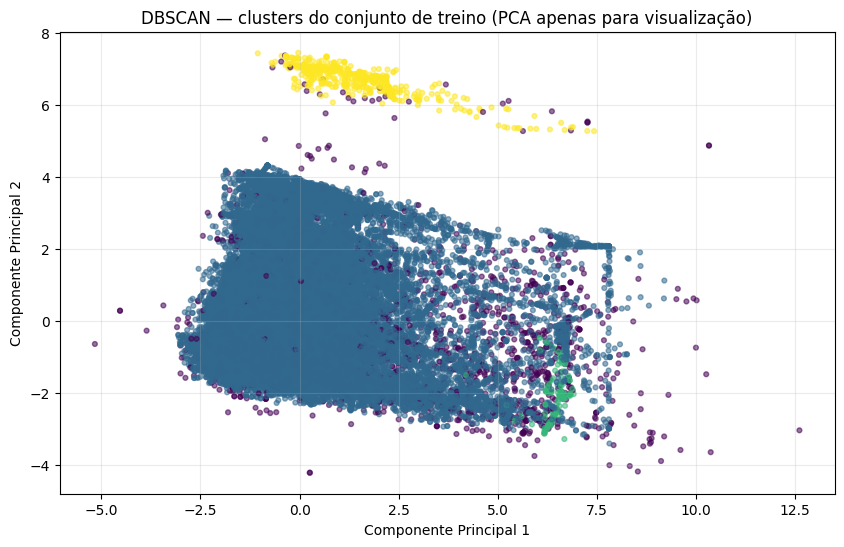

Variância explicada pelas 2 componentes: 22.66%


In [16]:
# Célula 6: visualização dos clusters

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_smote)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=cluster_train,
    alpha=0.55,
    s=12
)
plt.title("DBSCAN — clusters do conjunto de treino (PCA apenas para visualização)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(alpha=0.25)
plt.show()

print(
    "Variância explicada pelas 2 componentes:",
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

## Avaliação auxiliar como classificação

DBSCAN não possui `predict()` nativo. Para permitir uma comparação **auxiliar** com os classificadores do TCC:

1. cada cluster do treino é associado à classe majoritária observada nele;
2. cada registro de teste é ligado ao **core point** mais próximo se estiver dentro de `eps`;
3. registros sem core point próximo recebem `cluster = -1` (ruído);
4. o ruído recebe a classe majoritária do treino.

Essas métricas devem ser apresentadas como **análise auxiliar**, e não como equivalentes diretas às métricas de XGBoost.


Teste associado a clusters: 92.41%
Teste tratado como ruído: 7.59%


,Treino,Teste
Accuracy,0.5268,0.1695
Precision atraso,0.5139,0.1155
Recall atraso,0.9869,0.8907
F1 atraso,0.6759,0.2045
F2 atraso,0.8335,0.3803
Balanced Accuracy,0.5268,0.4810
MCC,0.1367,-0.0466


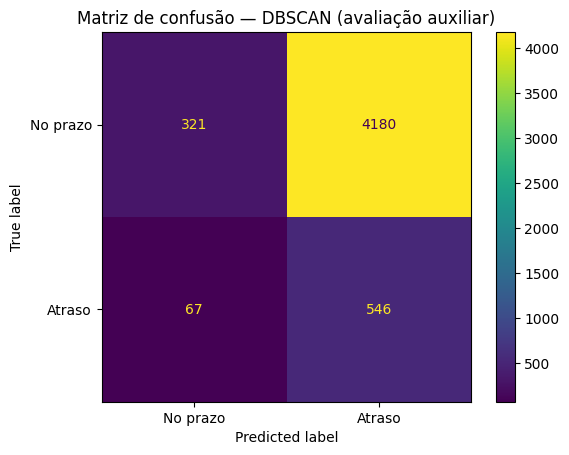

In [17]:
# Célula 7: atribuição dos dados de teste aos core points do DBSCAN

if len(dbscan_final.core_sample_indices_) == 0:
    raise RuntimeError("O DBSCAN final não encontrou core points.")

core_indices = dbscan_final.core_sample_indices_
X_core = X_train_smote.iloc[core_indices]
core_cluster_labels = cluster_train[core_indices]

nn_core = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nn_core.fit(X_core)

dist_test, idx_test = nn_core.kneighbors(X_test)
dist_test = dist_test.ravel()
idx_test = idx_test.ravel()

cluster_test = np.full(len(X_test), -1, dtype=int)
dentro_eps = dist_test <= best_eps
cluster_test[dentro_eps] = core_cluster_labels[idx_test[dentro_eps]]

print(f"Teste associado a clusters: {dentro_eps.mean():.2%}")
print(f"Teste tratado como ruído: {(~dentro_eps).mean():.2%}")

# Classe majoritária de cada cluster, calculada SOMENTE no treino.
classe_majoritaria_global = int(y_train_smote.mode().iloc[0])

cluster_to_class = (
    resultado_train[resultado_train["cluster"] != -1]
    .groupby("cluster")["atraso_real"]
    .mean()
    .ge(0.5)
    .astype(int)
    .to_dict()
)

y_pred_train = np.array([
    cluster_to_class.get(c, classe_majoritaria_global)
    for c in cluster_train
])

y_pred_test = np.array([
    cluster_to_class.get(c, classe_majoritaria_global)
    for c in cluster_test
])

def metricas_classificacao_auxiliar(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision atraso": precision_score(y_true, y_pred, zero_division=0),
        "Recall atraso": recall_score(y_true, y_pred, zero_division=0),
        "F1 atraso": f1_score(y_true, y_pred, zero_division=0),
        "F2 atraso": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

metricas_train = metricas_classificacao_auxiliar(y_train_smote, y_pred_train)
metricas_test = metricas_classificacao_auxiliar(y_test, y_pred_test)

df_metricas = pd.DataFrame({
    "Treino": metricas_train,
    "Teste": metricas_test
})

display(df_metricas.round(4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=["No prazo", "Atraso"]
)
plt.title("Matriz de confusão — DBSCAN (avaliação auxiliar)")
plt.show()

## Conclusão metodológica

Este notebook mantém o DBSCAN o mais comparável possível ao XGBoost em relação aos **dados de entrada e pré-processamento**, mas respeita a natureza não supervisionada do algoritmo.

Se Accuracy/Precision/Recall/F1/F2 forem usadas na tabela geral do TCC, recomenda-se marcar as métricas do DBSCAN como **auxiliares**, porque os clusters não são originalmente classes de atraso. Para avaliar o agrupamento em si, ARI, NMI, Silhouette Score, número de clusters e proporção de ruído são métricas mais adequadas.


## Exportação do modelo

Salva o DBSCAN e os artefatos necessários para reutilização na aplicação.

In [18]:
import pickle

artefatos_dbscan = {
    "modelo": dbscan_final,
    "scaler": scaler,
    "features": X_train.columns.tolist(),
    "eps": best_eps,
    "min_samples": best_min_samples,
    "cluster_to_class": cluster_to_class,
    "classe_majoritaria_global": classe_majoritaria_global,
    "core_samples": X_core,
    "core_cluster_labels": core_cluster_labels,
    "smote_sampling_strategy": "auto",
    "random_state": 42
}

with open("dbscan_model.pkl", "wb") as arquivo:
    pickle.dump(artefatos_dbscan, arquivo)

print("Arquivo 'dbscan_model.pkl' salvo com sucesso!")

Arquivo 'dbscan_model.pkl' salvo com sucesso!
